In [2]:
import gillespy2
import numpy as np
import os
import sys
import time
import matplotlib.pyplot as plt
import jsf as jsf
%matplotlib widget

from GillespieDirectMethod import gillespie_direct_method

In [3]:

class BirthDeathModel_GP2(gillespy2.Model):
    def __init__(self, x0=10, growth_rate=1, death_rate=0.5, t_max=5, switch_th=100, dt = 0.01):
        super().__init__(name="BirthDeathModel")
        
        # Parameters
        self.add_parameter(gillespy2.Parameter(name="k_birth", expression=growth_rate ))
        self.add_parameter(gillespy2.Parameter(name="k_death", expression=death_rate))
        
        # Species
        # self.add_species(gillespy2.Species(name="X", initial_value=x0, switch_min=switch_th, switch_tol=0.1))
        self.add_species(gillespy2.Species(name="X", initial_value=x0, constant=False, boundary_condition=False, mode='dynamic', allow_negative_populations=False,  switch_min=switch_th ))
        
        # Reactions
        self.add_reaction(gillespy2.Reaction(name="birth", reactants={'X': 1}, products={'X': 2}, rate=self.listOfParameters['k_birth']))
        self.add_reaction(gillespy2.Reaction(name="death", reactants={'X': 1}, products={}, rate=self.listOfParameters['k_death']))
        
        self.timespan(np.linspace(0, t_max, round(1+t_max/dt)))

def jsf_process(x0=10, growth_rate=1, death_rate=0.5, t_max=5, switch_th=100):
    # Implement the JSF process
    # Define the Parameters
    pgrowth = growth_rate
    pdeath = death_rate

    # Define the stoichiometry
    reactant_matrix =[[1],
                    [1]]

    product_matrix = [[2],
                    [0]]

    # Define the rates
    rates = lambda x, t: [pgrowth  * x[0],
                        pdeath * x[0]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }

    my_opts = {
                "EnforceDo": [0],
                "dt": 0.01,
                "SwitchingThreshold": [switch_th]
            }
    x0_v = [x0]

    sim_jsf = jsf.jsf(x0_v, rates, stoich, t_max, config=my_opts, method="operator-splitting")
    return sim_jsf

def ssa_process(x0=10, growth_rate=1, death_rate=0.5, t_max=5):
    # Implement the JSF process
    # Define the Parameters
    pgrowth = growth_rate
    pdeath = death_rate

    # Define the stoichiometry
    reactant_matrix =[[1],
                    [1]]

    product_matrix = [[2],
                    [0]]

    # Define the rates
    rates = lambda x, t: [pgrowth  * x[0],
                        pdeath * x[0]]

    stoich = {
            "nu": [ [a - b for a, b in zip(r1, r2)]
                    for r1, r2 in zip(product_matrix, reactant_matrix) ],
            "DoDisc": [0],
            "nuReactant": reactant_matrix,
            "nuProduct": product_matrix,
            }
    x0_v = [x0]

    sim_gil = gillespie_direct_method(x0, rates, stoich, [0, t_max], options=None)
    return sim_gil


In [3]:

x0=1
switch_th=100
growth_rate= 1.0
death_rate = 0.5
t_max= 20
numb_of_traj= 1000

common_time_grid = np.linspace(0, t_max, round(1+t_max/0.01))


hitting_value = 200

## Jump Switch Flow
summary_time_JSF_100 = []
summary_cpu_JSF_100 = np.zeros(numb_of_traj)
results_JSF_100 = []
results_JSF_exist_100 = []
summary_extinct_JSF_100 = 0

for i in range(numb_of_traj):
    start_time = time.perf_counter()
    jsf_sim = jsf_process(x0,growth_rate, death_rate, t_max, 100)
    end_time = time.perf_counter()

    summary_cpu_JSF_100[i] = end_time - start_time
    

    time_reached_100_JSF = None
    x_p = 0
    for t, x in zip(jsf_sim[1], jsf_sim[0][0]):
        if growth_rate > death_rate:
            if x >= hitting_value and x_p < hitting_value:
                time_reached_100_JSF = t
                summary_time_JSF_100.append(time_reached_100_JSF)
                break
        else:
            if x <= hitting_value and x_p > hitting_value:
                time_reached_100_JSF = t
                summary_time_JSF_100.append(time_reached_100_JSF)
        x_p = x

    # interpolate results onto a common time grid
    t_common = common_time_grid
    x_common = np.interp(t_common, jsf_sim[1], jsf_sim[0][0])
    # store the results 
    results_JSF_100.append({'time': t_common, 'X': x_common})

    if jsf_sim[0][0][-1] == 0:
        summary_extinct_JSF_100 += 1
    else:
        results_JSF_exist_100.append({'time': t_common, 'X': x_common})

summary_time_JSF_10 = []
summary_cpu_JSF_10 = np.zeros(numb_of_traj)
results_JSF_10 = []
results_JSF_exist_10 = []
summary_extinct_JSF_10 = 0

for i in range(numb_of_traj):
    start_time = time.perf_counter()
    jsf_sim = jsf_process(x0,growth_rate, death_rate, t_max, 10)
    end_time = time.perf_counter()

    summary_cpu_JSF_10[i] = end_time - start_time
    

    time_reached_100_JSF = None
    x_p = 0
    for t, x in zip(jsf_sim[1], jsf_sim[0][0]):
        if growth_rate > death_rate:
            if x >= hitting_value and x_p < hitting_value:
                time_reached_100_JSF = t
                summary_time_JSF_10.append(time_reached_100_JSF)
                break
        else:
            if x <= hitting_value and x_p > hitting_value:
                time_reached_100_JSF = t
                summary_time_JSF_10.append(time_reached_100_JSF)
        x_p = x

    # interpolate results onto a common time grid
    t_common = common_time_grid
    x_common = np.interp(t_common, jsf_sim[1], jsf_sim[0][0])
    # store the results 
    results_JSF_10.append({'time': t_common, 'X': x_common})

    if jsf_sim[0][0][-1] == 0:
        summary_extinct_JSF_10 += 1
    else:
        results_JSF_exist_10.append({'time': t_common, 'X': x_common})


summary_time_JSF_1000 = []
summary_cpu_JSF_1000 = np.zeros(numb_of_traj)
results_JSF_1000 = []
results_JSF_exist_1000 = []
summary_extinct_JSF_1000 = 0

for i in range(numb_of_traj):
    start_time = time.perf_counter()
    jsf_sim = jsf_process(x0,growth_rate, death_rate, t_max, 1000)
    end_time = time.perf_counter()

    summary_cpu_JSF_1000[i] = end_time - start_time
    

    time_reached_100_JSF = None
    x_p = 0
    for t, x in zip(jsf_sim[1], jsf_sim[0][0]):
        if growth_rate > death_rate:
            if x >= hitting_value and x_p < hitting_value:
                time_reached_100_JSF = t
                summary_time_JSF_1000.append(time_reached_100_JSF)
                break
        else:
            if x <= hitting_value and x_p > hitting_value:
                time_reached_100_JSF = t
                summary_time_JSF_1000.append(time_reached_100_JSF)
        x_p = x

    # interpolate results onto a common time grid
    t_common = common_time_grid
    x_common = np.interp(t_common, jsf_sim[1], jsf_sim[0][0])
    # store the results 
    results_JSF_1000.append({'time': t_common, 'X': x_common})

    if jsf_sim[0][0][-1] == 0:
        summary_extinct_JSF_1000 += 1
    else:
        results_JSF_exist_1000.append({'time': t_common, 'X': x_common})

## Tau-Hybrid
summary_time_GP2 = []
summary_cpu_GP2 = 0
summary_extinct_GP2 = 0

results_GP2_exist = []

model = BirthDeathModel_GP2(x0, growth_rate, death_rate, t_max, switch_th)

start_time = time.perf_counter()
results_tau_hyb = model.run(algorithm="Tau-Hybrid", number_of_trajectories=numb_of_traj )

end_time = time.perf_counter()
summary_cpu_GP2 = (end_time - start_time)/numb_of_traj

for i in range(numb_of_traj):
    time_reached_100_GP2 = None
    x_p = 0
    for t, x in zip(results_tau_hyb[i]['time'], results_tau_hyb[i]['X']):
        if growth_rate > death_rate:
            if x >= hitting_value and x_p < hitting_value:
                time_reached_100_GP2 = t
                summary_time_GP2.append(time_reached_100_GP2)
                break
        else:
            if x <= hitting_value and x_p > hitting_value:
                time_reached_100_GP2 = t
                summary_time_GP2.append(time_reached_100_GP2)
        x_p = x

    if results_tau_hyb[i]['X'][-1] == 0:
        summary_extinct_GP2 += 1
    else:
        results_GP2_exist.append({'time': results_tau_hyb[i]['time'], 'X': results_tau_hyb[i]['X']})



## Gillespie Direct Method
summary_cpu_Gil = 0
summary_time_Gil = []

summary_extinct_SSA = 0

results_SSA_exist = []

start_time = time.perf_counter()
results_SSA = model.run(algorithm="SSA", number_of_trajectories=numb_of_traj )
end_time = time.perf_counter()
summary_cpu_Gil = (end_time - start_time)/numb_of_traj

for i in range(numb_of_traj):
    time_reached_100_Gil = None
    x_p = 0
    for t, x in zip(results_SSA[i]['time'], results_SSA[i]['X']):
        if growth_rate > death_rate:
            if x >= hitting_value and x_p < hitting_value:
                time_reached_100_Gil = t
                summary_time_Gil.append(time_reached_100_Gil)
                break
        else:
            if x <= hitting_value and x_p > hitting_value:
                time_reached_100_Gil = t
                summary_time_Gil.append(time_reached_100_Gil)
        x_p = x

    if results_SSA[i]['X'][-1] == 0:
        summary_extinct_SSA += 1
    else:
        results_SSA_exist.append({'time': results_SSA[i]['time'], 'X': results_SSA[i]['X']})



summary_extinct_GP2 = summary_extinct_GP2/numb_of_traj
summary_extinct_SSA = summary_extinct_SSA/numb_of_traj
summary_extinct_JSF_10 = summary_extinct_JSF_10/numb_of_traj
summary_extinct_JSF_100 = summary_extinct_JSF_100/numb_of_traj
summary_extinct_JSF_1000 = summary_extinct_JSF_1000/numb_of_traj

ext_prob_GP2_error = np.sqrt(summary_extinct_GP2*(1-summary_extinct_GP2)/numb_of_traj)
ext_prob_SSA_error = np.sqrt(summary_extinct_SSA*(1-summary_extinct_SSA)/numb_of_traj)
ext_prob_JSF_100_error = np.sqrt(summary_extinct_JSF_100*(1-summary_extinct_JSF_100)/numb_of_traj)

ext_prob_JSF_10_error = np.sqrt(summary_extinct_JSF_10*(1-summary_extinct_JSF_10)/numb_of_traj)
ext_prob_JSF_1000_error = np.sqrt(summary_extinct_JSF_1000*(1-summary_extinct_JSF_1000)/numb_of_traj)

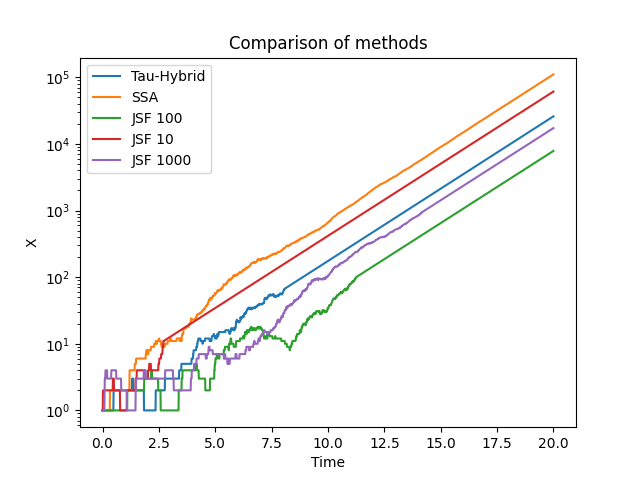

In [4]:
# plot an instance, i, of the results from each method
i = 2
plt.figure()
plt.plot(results_GP2_exist[i]['time'], results_GP2_exist[i]['X'], label='Tau-Hybrid')
plt.plot(results_SSA_exist[i]['time'], results_SSA_exist[i]['X'], label='SSA')
plt.plot(results_JSF_exist_100[i]['time'], results_JSF_exist_100[i]['X'], label='JSF 100')
plt.plot(results_JSF_exist_10[i]['time'], results_JSF_exist_10[i]['X'], label='JSF 10')
plt.plot(results_JSF_exist_1000[i]['time'], results_JSF_exist_1000[i]['X'], label='JSF 1000')
plt.legend()
plt.xlabel('Time')
plt.ylabel('X')
plt.title('Comparison of methods')
plt.yscale('log')
plt.show()


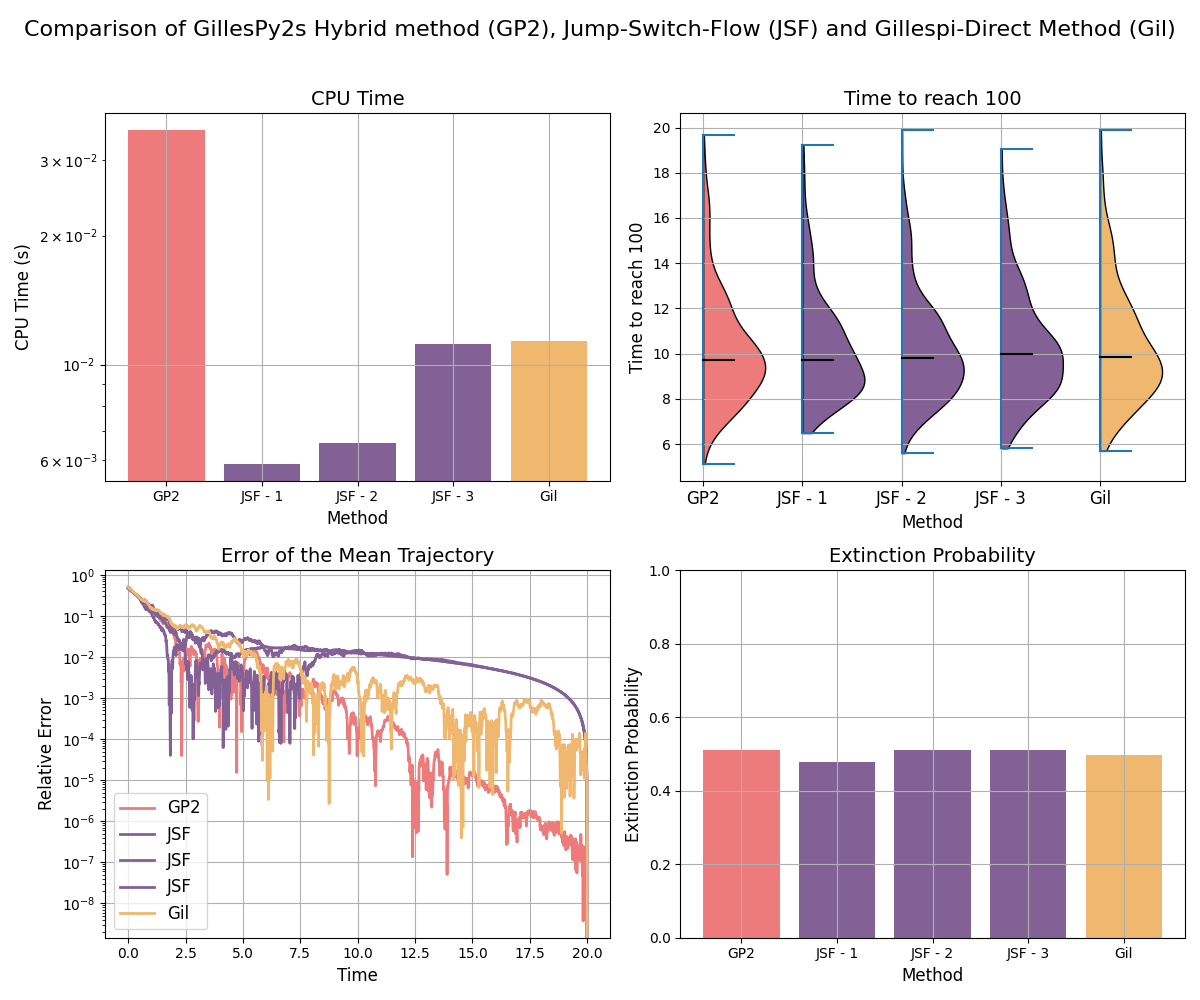

In [5]:
jsf_color = (131/255, 96/255, 150/255)
gp2_color = (237/255, 123/255, 123/255)
gil_color = (240/255, 184/255, 110/255)

labels = ['GP2', 'JSF - 1', 'JSF - 2', 'JSF - 3', 'Gil']

# Create a subplot
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Comparison of GillesPy2s Hybrid method (GP2), Jump-Switch-Flow (JSF) and Gillespi-Direct Method (Gil)', fontsize=16)

# Plot the point estimate of the mean of summary_cpu_GP2 and summary_cpu_JSF
axs[0, 0].bar(labels, [summary_cpu_GP2, np.mean(summary_cpu_JSF_10), np.mean(summary_cpu_JSF_100), np.mean(summary_cpu_JSF_1000), np.mean(summary_cpu_Gil)], 
              color=[gp2_color, jsf_color, jsf_color, jsf_color, gil_color])
axs[0, 0].set_xlabel('Method', fontsize=12)
axs[0, 0].set_ylabel('CPU Time (s)', fontsize=12)
axs[0, 0].set_title('CPU Time', fontsize=14)
axs[0, 0].set_yscale('log')
axs[0, 0].grid(True)

# Plot the violin plot of summary_time_GP2 and summary_time_JSF
parts = axs[0, 1].violinplot([summary_time_GP2, summary_time_JSF_10, summary_time_JSF_100, summary_time_JSF_1000, summary_time_Gil], showmedians=True, side='high', widths=1.25)
colors = [gp2_color, jsf_color, jsf_color, jsf_color, gil_color]
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(1)

parts['cmedians'].set_color('black')
axs[0, 1].set_xticks([1, 2, 3, 4, 5])
axs[0, 1].set_xticklabels(labels, fontsize=12)
axs[0, 1].set_xlabel('Method', fontsize=12)
axs[0, 1].set_ylabel('Time to reach 100', fontsize=12)
axs[0, 1].set_title('Time to reach 100', fontsize=14)
axs[0, 1].grid(True)

# Plot the bar plot of extinction frequency
axs[1, 1].bar(labels, [summary_extinct_GP2, summary_extinct_JSF_10, summary_extinct_JSF_100, summary_extinct_JSF_1000, summary_extinct_SSA], color=[gp2_color, jsf_color, jsf_color, jsf_color, gil_color])
axs[1, 1].set_xlabel('Method', fontsize=12)
axs[1, 1].set_ylabel('Extinction Probability', fontsize=12)
axs[1, 1].set_title('Extinction Probability', fontsize=14)
axs[1, 1].set_ylim(0, 1)
axs[1, 1].grid(True)

# Calculate mean trajectories
mean_X_JSF_10 = np.mean([res['X'] for res in results_JSF_exist_10], axis=0)
mean_X_JSF_100 = np.mean([res['X'] for res in results_JSF_exist_100], axis=0)
mean_X_JSF_1000 = np.mean([res['X'] for res in results_JSF_exist_1000], axis=0)
mean_X_GP2 = np.mean([res['X'] for res in results_GP2_exist], axis=0)
mean_X_Gil = np.mean([res['X'] for res in results_SSA_exist], axis=0)

analytic_sol = lambda t, t0=t_max, x0=x0: x0 * np.exp((growth_rate - death_rate) * (t - t0))
mean_end = (mean_X_JSF_10[-1] + mean_X_JSF_100[-1] + mean_X_JSF_1000[-1] + mean_X_GP2[-1] + mean_X_Gil[-1]) / 3

error_jsf_10 = np.abs(analytic_sol(results_JSF_10[0]['time'], t_max, mean_X_JSF_10[-1]) - mean_X_JSF_10)/analytic_sol(results_JSF_10[0]['time'], t_max, mean_X_JSF_10[-1])
error_jsf_100 = np.abs(analytic_sol(results_JSF_100[0]['time'], t_max, mean_X_JSF_100[-1]) - mean_X_JSF_100)/analytic_sol(results_JSF_100[0]['time'], t_max, mean_X_JSF_100[-1])
error_jsf_1000 = np.abs(analytic_sol(results_JSF_1000[0]['time'], t_max, mean_X_JSF_1000[-1]) - mean_X_JSF_1000)/analytic_sol(results_JSF_1000[0]['time'], t_max, mean_X_JSF_1000[-1])
error_gp2 = np.abs(analytic_sol(results_GP2_exist[0]['time'], t_max, mean_X_GP2[-1]) - mean_X_GP2)/analytic_sol(results_GP2_exist[0]['time'], t_max, mean_X_GP2[-1])
error_gil = np.abs(analytic_sol(results_SSA_exist[0]['time'], t_max, mean_X_Gil[-1]) - mean_X_Gil)/analytic_sol(results_SSA_exist[0]['time'], t_max, mean_X_Gil[-1])

# Plot the error of the mean trajectory
axs[1, 0].plot(results_tau_hyb[0]['time'], error_gp2, label='GP2', color=gp2_color, linewidth=2)
axs[1, 0].plot(results_JSF_10[0]['time'],     error_jsf_10, label='JSF', color=jsf_color, linewidth=2)
axs[1, 0].plot(results_JSF_100[0]['time'],     error_jsf_100, label='JSF', color=jsf_color, linewidth=2)
axs[1, 0].plot(results_JSF_1000[0]['time'],     error_jsf_1000, label='JSF', color=jsf_color, linewidth=2)
axs[1, 0].plot(results_SSA[0]['time'],     error_gil, label='Gil', color=gil_color, linewidth=2)
axs[1, 0].set_xlabel('Time', fontsize=12)
axs[1, 0].set_ylabel('Relative Error', fontsize=12)
axs[1, 0].set_title('Error of the Mean Trajectory', fontsize=14)
axs[1, 0].legend(fontsize=12)
axs[1, 0].set_yscale('log')
axs[1, 0].grid(True)

# Hide the last subplot (1, 2) if not used

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_83393/1837341704.py:5: SyntaxWarning: invalid escape sequence '\O'
  labels = ['Tau-Hybrid', 'JSF: $\Omega = 10^1$', 'JSF: $\Omega = 10^2$', 'JSF: $\Omega = 10^3$', 'Doob-Gillespie']
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_83393/1837341704.py:5: SyntaxWarning: invalid escape sequence '\O'
  labels = ['Tau-Hybrid', 'JSF: $\Omega = 10^1$', 'JSF: $\Omega = 10^2$', 'JSF: $\Omega = 10^3$', 'Doob-Gillespie']
/var/folders/w6/dtzmmv853z34h6pgfd8gvx880000gp/T/ipykernel_83393/1837341704.py:5: SyntaxWarning: invalid escape sequence '\O'
  labels = ['Tau-Hybrid', 'JSF: $\Omega = 10^1$', 'JSF: $\Omega = 10^2$', 'JSF: $\Omega = 

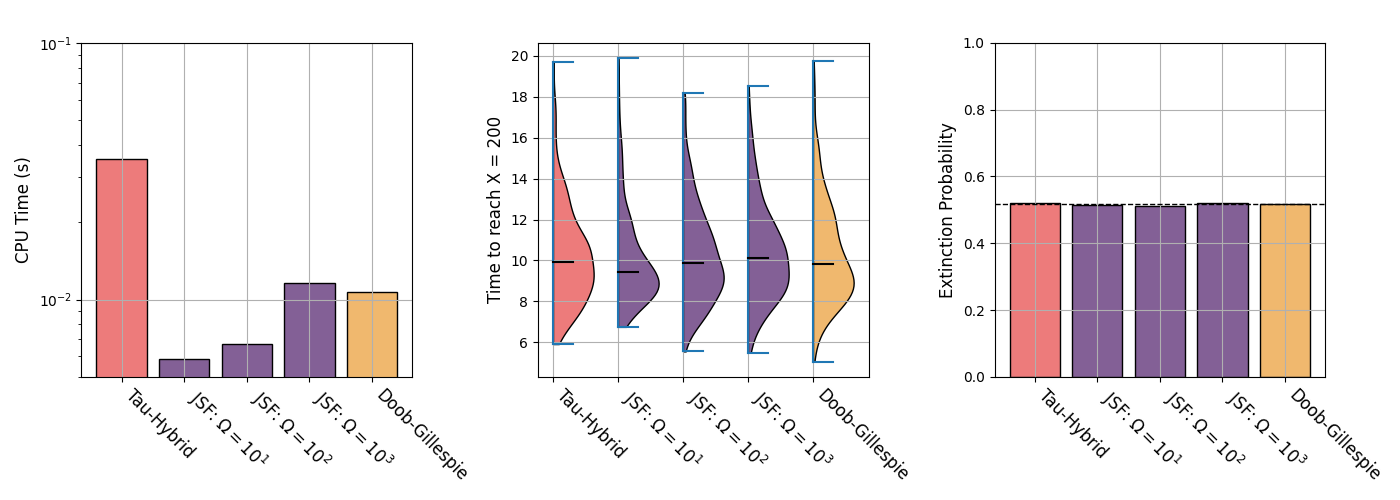

In [50]:
jsf_color = (131/255, 96/255, 150/255)
gp2_color = (237/255, 123/255, 123/255)
gil_color = (240/255, 184/255, 110/255)

labels = ['Tau-Hybrid', 'JSF: $\Omega = 10^1$', 'JSF: $\Omega = 10^2$', 'JSF: $\Omega = 10^3$', 'Doob-Gillespie']

# Create a subplot
fig, axs = plt.subplots(1, 3, figsize=(14, 5))
# fig.suptitle('Comparison of GillesPy2s Hybrid method (GP2), Jump-Switch-Flow (JSF) and Gillespi-Direct Method (Gil)', fontsize=16)

# Plot the point estimate of the mean of summary_cpu_GP2 and summary_cpu_JSF
axs[0].bar(labels, [summary_cpu_GP2, np.mean(summary_cpu_JSF_10), np.mean(summary_cpu_JSF_100), np.mean(summary_cpu_JSF_1000), np.mean(summary_cpu_Gil)], 
              color=[gp2_color, jsf_color, jsf_color, jsf_color, gil_color], edgecolor='black')
# axs[0].set_xlabel('Method', fontsize=12)
axs[0].set_ylabel('CPU Time (s)', fontsize=12)
# axs[0].set_title('CPU Time', fontsize=14)
axs[0].set_yscale('log')
axs[0].grid(True)
axs[0].set_xticklabels(labels, fontsize=12, rotation=-45, ha='left')
axs[0].set_ylim(5*10**-3, 10**-1)



# Plot the violin plot of summary_time_GP2 and summary_time_JSF
parts = axs[1].violinplot([summary_time_GP2, summary_time_JSF_10, summary_time_JSF_100, summary_time_JSF_1000, summary_time_Gil], showmedians=True, side='high', widths=1.25)
colors = [gp2_color, jsf_color, jsf_color, jsf_color, gil_color]
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(1)

parts['cmedians'].set_color('black')
axs[1].set_xticks([1, 2, 3, 4, 5])
axs[1].set_xticklabels(labels, fontsize=12, rotation=-45, ha='left')
# axs[1].set_xlabel('Method', fontsize=12)
axs[1].set_ylabel(f'Time to reach X = {hitting_value}', fontsize=12)
# axs[1].set_title(f'Time to reach {hitting_value}', fontsize=14)
axs[1].grid(True)

# Plot the bar plot of extinction frequency
axs[2].axhline(y=summary_extinct_SSA, color='black', linestyle='--', linewidth=1, label=f'SSA: {summary_extinct_SSA:.3f}')
axs[2].bar(labels, [summary_extinct_GP2, summary_extinct_JSF_10, summary_extinct_JSF_100, summary_extinct_JSF_1000, summary_extinct_SSA], 
           color=[gp2_color, jsf_color, jsf_color, jsf_color, gil_color], edgecolor='black')
# axs[2].set_xlabel('Method', fontsize=12)
axs[2].set_ylabel('Extinction Probability', fontsize=12)
# axs[2].set_title('Extinction Probability', fontsize=14)
axs[2].set_ylim(0, 1)
axs[2].grid(True)
axs[2].set_xticklabels(labels, fontsize=12, rotation=-45, ha='left')


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

plt.savefig('BD-Process_birth-drive.pdf')

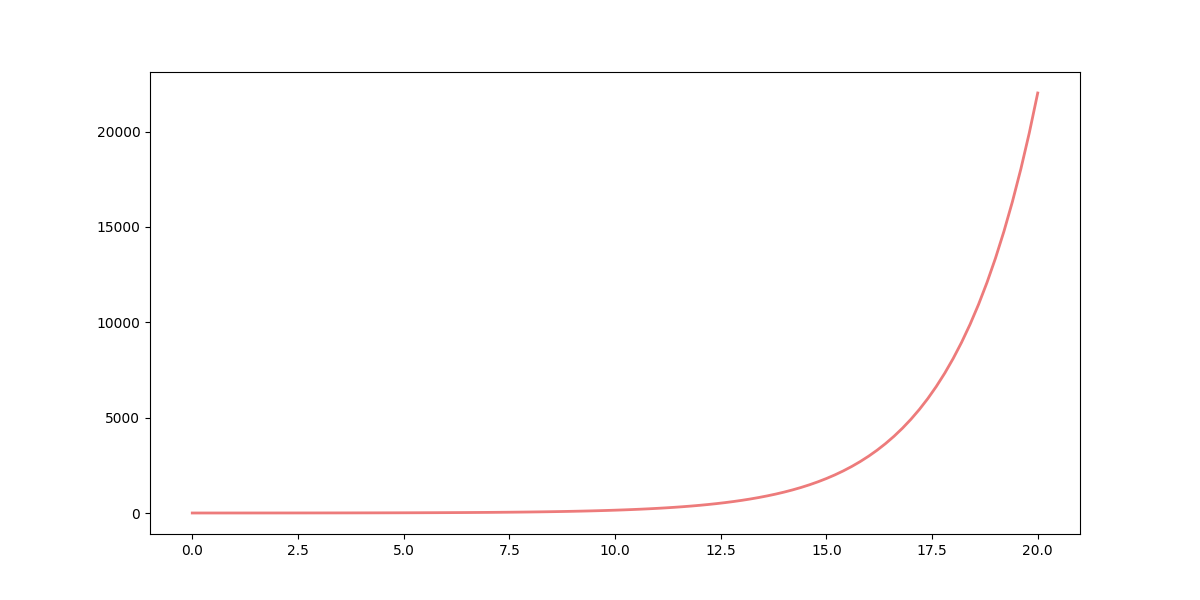

In [6]:
x0=1
switch_th=100
growth_rate= 1.0
death_rate = 0.5
t_max= 5
analytic_sol = lambda t, t0=0, x0=x0: x0 * np.exp((growth_rate - death_rate) * (t - t0))
tm = np.linspace(0,20,101)
# Plot the mean trajectory of the results
plt.figure(figsize=(12, 6))
plt.plot(tm, analytic_sol(tm, 0, 1), label='GP2', color=gp2_color, linewidth=2)